In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import GComputation, pairwise  # 0.4.0: Margins -> GComputation

raw = sm.datasets.fair.load_pandas().data.copy()
raw["had_affair"] = (raw["affairs"] > 0).astype(int)
print(raw[["had_affair", "affairs", "age", "yrs_married",
           "religious", "rate_marriage"]].describe().round(2))

       had_affair  affairs      age  yrs_married  religious  rate_marriage
count     6366.00  6366.00  6366.00      6366.00    6366.00        6366.00
mean         0.32     0.71    29.08         9.01       2.43           4.11
std          0.47     2.20     6.85         7.28       0.88           0.96
min          0.00     0.00    17.50         0.50       1.00           1.00
25%          0.00     0.00    22.00         2.50       2.00           4.00
50%          0.00     0.00    27.00         6.00       2.00           4.00
75%          1.00     0.48    32.00        16.50       3.00           5.00
max          1.00    57.60    42.00        23.00       4.00           5.00


In [2]:
logit = smf.glm(
    "had_affair ~ age + yrs_married + religious + rate_marriage + educ",
    data=raw,
    family=sm.families.Binomial(),
).fit()

m_logit = GComputation(logit, vcov="HC3", at="overall", scale="identity")
print(m_logit.dydx(["age", "yrs_married", "religious",
                    "rate_marriage", "educ"]).summary())

                  Graph Result (delta, level=0.95)                 
               estimate  std err         z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------------
age             -0.0107   0.0018   -5.8172  0.000  -0.0143, -0.0071
yrs_married      0.0196   0.0017   11.8120  0.000    0.0164, 0.0229
religious       -0.0679   0.0063  -10.8099  0.000  -0.0802, -0.0556
rate_marriage   -0.1275   0.0066  -19.4033  0.000  -0.1404, -0.1146
educ            -0.0021   0.0026   -0.7967  0.426   -0.0073, 0.0031

n = 6366
Delta-vs-sim disagreement: 14.243%
plan bbec7c6@1 | κ = max 0.084


In [3]:
pois = smf.glm(
    "affairs ~ age + yrs_married + religious + rate_marriage + educ",
    data=raw,
    family=sm.families.Poisson(),
).fit()

m_pois = GComputation(pois, vcov="HC3", at="overall", scale="identity")
print(m_pois.dydx(["age", "yrs_married", "religious",
                   "rate_marriage", "educ"]).summary())

                  Graph Result (delta, level=0.95)                 
               estimate  std err         z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------------
age             -0.0155   0.0099   -1.5734  0.116   -0.0348, 0.0038
yrs_married     -0.0281   0.0118   -2.3736  0.018  -0.0513, -0.0049
religious       -0.2573   0.0503   -5.1158  0.000  -0.3558, -0.1587
rate_marriage   -0.3511   0.0257  -13.6737  0.000  -0.4014, -0.3007
educ            -0.0070   0.0157   -0.4432  0.658   -0.0377, 0.0238

n = 6366
Delta-vs-sim disagreement: 117.857%
plan bbec7c6@1 | κ = max 0.602


In [4]:
scen, w = pairwise("rate_marriage", [5, 1])
print("Logit (probability scale):")
print(m_logit.contrasts(scenarios=scen, contrasts=w).summary())
print("\nPoisson (count scale):")
print(m_pois.contrasts(scenarios=scen, contrasts=w).summary())

Logit (probability scale):


                   Graph Result (delta, level=0.95)                  
                 estimate  std err         z  P>|z|  [95% Conf. Int.]
---------------------------------------------------------------------
rate_marriage=5   -0.5819   0.0209  -27.8855  0.000  -0.6228, -0.5410

n = 6366
Delta-vs-sim disagreement: 0.813%
plan bbec7c6@1 | κ = 0.043

Poisson (count scale):
                  Graph Result (delta, level=0.95)                  
                 estimate  std err        z  P>|z|  [95% Conf. Int.]
--------------------------------------------------------------------
rate_marriage=5   -2.5910   0.2767  -9.3637  0.000  -3.1333, -2.0486

n = 6366
Delta-vs-sim disagreement: 0.612%
plan bbec7c6@1 | κ = 0.089


In [5]:
m_pois_log = GComputation(pois, vcov="HC3", at="overall", scale="log")
rr = m_pois_log.contrasts(scenarios=scen, contrasts=w)
print(rr.summary())

                   Graph Result (delta, level=0.95)                  
                 estimate  std err         z  P>|z|  [95% Conf. Int.]
---------------------------------------------------------------------
rate_marriage=5    0.1336   0.1240  -16.2310  0.000    0.1048, 0.1704

n = 6366
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
Delta-vs-sim disagreement: 0.843%
plan 341e13f@1 | κ = 0.000


In [6]:
print(rr.kappa)
print(m_pois_log.plan.describe())

5.797889432586684e-08
Plan 341e13f@1
  method: delta (declared: delta)
  resolution reason: user-specified
  scale: log
  at: overall
  ci: wald
  level: 0.95
  B: 1000
  n_sim: 4000
  seed: None
  data fingerprint: 4918cf43fee65508...


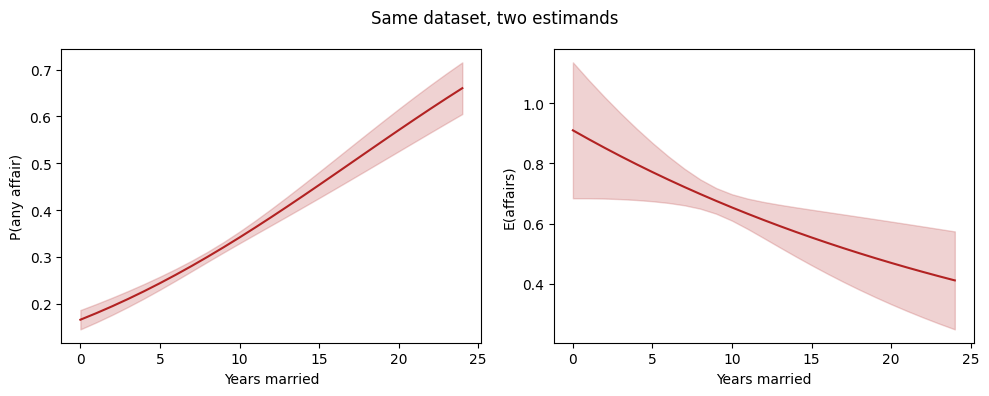

In [7]:
import matplotlib.pyplot as plt

years = list(range(0, 25))
res_l = m_logit.predict(atexog={"yrs_married": years})
res_p = m_pois.predict(atexog={"yrs_married": years})

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for ax, res, ylabel in [
    (axes[0], res_l, "P(any affair)"),
    (axes[1], res_p, "E(affairs)"),
]:
    d = res.to_frame()
    ax.plot(d["yrs_married"], d["estimate"], color="firebrick")
    ax.fill_between(
        d["yrs_married"], d["ci_lower"], d["ci_upper"],
        alpha=0.2, color="firebrick",
    )
    ax.set(xlabel="Years married", ylabel=ylabel)
fig.suptitle("Same dataset, two estimands")
fig.tight_layout()